XGBoost Accuracy: 0.935


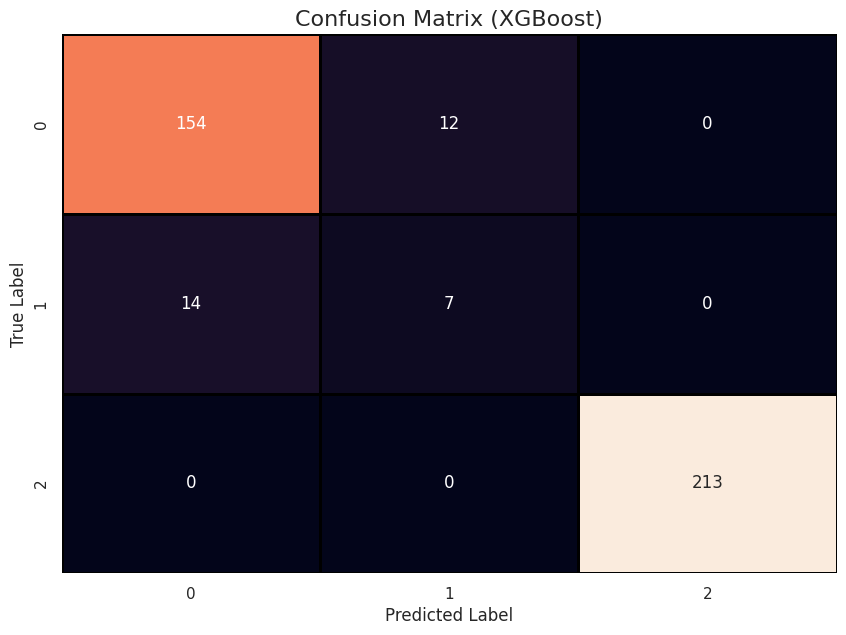

NameError: name 'LogisticRegression' is not defined

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LinearRegression
# Import XGBoost
from xgboost import XGBClassifier

df = pd.read_csv('ai_job_impact.csv')

# Encoding categorical variables
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

X = df.drop('Job_Status', axis=1)
y = df['Job_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train XGBoost Classifier
model = XGBClassifier(
    n_estimators=200,
    max_depth=10,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

rf_pred = model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, rf_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', linewidths=1, linecolor='black', cbar=False)
plt.title("Confusion Matrix (XGBoost)", fontsize=16)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Logistic Regression Comparison
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

X = df.drop('Job_Status', axis=1)
y = df['Job_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier(
    n_estimators=200,        # number of trees
    max_depth=10,            # limit tree depth (avoid overfitting)
    min_samples_split=5,     # minimum samples to split
    min_samples_leaf=2,      # minimum samples at leaf
    max_features='sqrt',     # features per split
    random_state=42,
    n_jobs=-1                # use all CPU cores
)
model.fit(X_train, y_train)

rf_pred = model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))



In [ ]:
import pandas as pd

# Memastikan data dimuat sebelum menampilkan statistik
df = pd.read_csv('ai_job_impact.csv')

# Tampilkan ringkasan statistik untuk seluruh kolom (numerik dan kategorikal)
summary_df = df.describe(include='all')
display(summary_df)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# 1. Load Data
df = pd.read_csv('ai_job_impact.csv')

# 2. Preprocessing
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

X = df.drop('Job_Status', axis=1)
y = df['Job_Status']

# Membagi data satu kali untuk semua model (random_state tetap)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling khusus untuk model sensitif jarak (KNN, LogReg, MLP)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# 3. Definisi Model
models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000), True),
    'Random Forest': (RandomForestClassifier(n_estimators=200, random_state=42), False),
    'XGBoost': (XGBClassifier(n_estimators=200, random_state=42), False),
    'Decision Tree': (DecisionTreeClassifier(random_state=42), False),
    'KNN': (KNeighborsClassifier(n_neighbors=5), True),
    'Naive Bayes': (GaussianNB(), False),
    'Neural Network (MLP)': (MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42), True)
}

# 4. Pelatihan dan Evaluasi
final_results = {}
for name, (model, needs_scaling) in models.items():
    X_tr = X_train_scaled if needs_scaling else X_train_raw
    X_ts = X_test_scaled if needs_scaling else X_test_raw

    model.fit(X_tr, y_train)
    pred = model.predict(X_ts)
    acc = accuracy_score(y_test, pred)
    final_results[name] = acc

# 5. Visualisasi
comparison_df = pd.DataFrame(list(final_results.items()), columns=['Algorithm', 'Accuracy']).sort_values(by='Accuracy', ascending=False)
display(comparison_df)

plt.figure(figsize=(12, 6))
sns.barplot(x='Accuracy', y='Algorithm', data=comparison_df, palette='magma')
plt.title('Perbandingan Akurasi Algoritma (Koreksi Total)')
plt.xlim(0, 1.1)
for i, val in enumerate(comparison_df['Accuracy']):
    plt.text(val + 0.01, i, f'{val:.4f}', va='center')
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Memastikan LabelEncoder memiliki class yang benar
# Kita ambil data asli lagi untuk mendapatkan mapping label yang tepat
df_original = pd.read_csv('ai_job_impact.csv')
le_status = LabelEncoder()
le_status.fit(df_original['Job_Status'])

# Mengambil model terbaik dari dictionary 'models'
best_model_name = 'Neural Network (MLP)'
best_model, needs_scaling = models[best_model_name]

# Menentukan data input yang sesuai
X_input = X_test_scaled if needs_scaling else X_test_raw

# Prediksi
y_pred_best = best_model.predict(X_input)

# Membuat Confusion Matrix
cm_best = confusion_matrix(y_test, y_pred_best)

# Visualisasi
plt.figure(figsize=(8, 6))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_status.classes_, yticklabels=le_status.classes_)
plt.title(f'Confusion Matrix: {best_model_name}')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Menampilkan Classification Report
print(f"\nClassification Report for {best_model_name}:\n")
print(classification_report(y_test, y_pred_best, target_names=le_status.classes_))

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mengambil model XGBoost dari dictionary models
xgb_model = models['XGBoost'][0]

# Mengambil skor feature importance
importances = xgb_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Visualisasi
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Faktor Utama yang Mempengaruhi Job Status (XGBoost Feature Importance)')
plt.xlabel('Tingkat Kepentingan (Importance Score)')
plt.ylabel('Fitur/Variabel')
plt.show()

# Menampilkan 5 fitur teratas
print("5 Faktor Terpenting:")
display(feature_importance_df.head(5))

### Visualisasi Fitur Penting (Tanpa Automation Risk)
Untuk melihat kontribusi fitur lain dengan lebih jelas, kita akan menghilangkan fitur dominan 'Automation Risk' dari plot.

In [ ]:
# Menghapus Automation Risk untuk melihat detail fitur lainnya
feature_importance_others = feature_importance_df[feature_importance_df['Feature'] != 'Automation_Risk']

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_others, palette='magma')
plt.title('Faktor Penting Lainnya (Tanpa Automation Risk)')
plt.xlabel('Importance Score')
plt.ylabel('Fitur')
plt.show()

print("Detail Fitur Lainnya:")
display(feature_importance_others.head(10))

### Visualisasi Seluruh Fitur (Termasuk Automation Risk)
Plot ini menunjukkan kontribusi relatif dari setiap variabel dalam dataset terhadap prediksi status pekerjaan.

In [ ]:
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Tingkat Kepentingan Seluruh Fitur (XGBoost)')
plt.xlabel('Importance Score')
plt.ylabel('Fitur')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Menampilkan tabel lengkap untuk referensi nilai numerik
print("Daftar Lengkap Feature Importance:")
display(feature_importance_df)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Load Data
df = pd.read_csv('ai_job_impact.csv')

# 2. Preprocessing
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

X = df.drop('Job_Status', axis=1)
y = df['Job_Status']

# Membagi data
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Latih model XGBoost dengan parameter hasil tuning
xgb_final = XGBClassifier(learning_rate=0.01, max_depth=3, n_estimators=200, random_state=42)
xgb_final.fit(X_train_raw, y_train)

# 4. Mengambil skor feature importance
importances = xgb_final.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 5. Membuat plot
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')

# Menambahkan label dan judul
plt.title('Fitur Terpenting dalam Memprediksi Job Status (XGBoost)', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Fitur', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Menambahkan nilai di ujung bar
for i, val in enumerate(feature_importance_df['Importance']):
    plt.text(val + 0.005, i, f'{val:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Pastikan data siap
df = pd.read_csv('ai_job_impact.csv')
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

X = df.drop('Job_Status', axis=1)
y = df['Job_Status']

# 2. Split data
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Latih model XGBoost dengan parameter optimal
xgb_final = XGBClassifier(learning_rate=0.01, max_depth=3, n_estimators=200, random_state=42)
xgb_final.fit(X_train_raw, y_train)

# 4. Ambil skor feature importance
importances = xgb_final.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 5. Visualisasi
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')

plt.title('Fitur Terpenting dalam Memprediksi Job Status (XGBoost)', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Fitur', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

for i, val in enumerate(feature_importance_df['Importance']):
    plt.text(val + 0.005, i, f'{val:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

# Memastikan model MLP tersedia
try:
    # Mencoba mengambil dari dictionary global jika ada
    mlp_model = all_models['Neural Network (MLP)'][0]
except (NameError, KeyError):
    print("Menyiapkan data dan mendefinisikan ulang model MLP...")
    # Penskalaan data di dalam sel untuk keamanan
    scaler_mlp = StandardScaler()
    X_train_scaled_local = scaler_mlp.fit_transform(X_train_raw)

    mlp_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
    mlp_model.fit(X_train_scaled_local, y_train)

# Neural Network tidak memiliki feature_importances_, tapi kita bisa melihat bobot (coefs_)
# Kita ambil nilai absolut rata-rata dari bobot di lapisan pertama (input layer)
importances_mlp = np.mean(np.abs(mlp_model.coefs_[0]), axis=1)
feature_names = X.columns

mlp_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances_mlp})
mlp_importance_df = mlp_importance_df.sort_values(by='Importance', ascending=False)

# Visualisasi
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=mlp_importance_df, palette='magma', hue='Feature', legend=False)
plt.title('Estimasi Pentingnya Fitur pada Neural Network (Berdasarkan Bobot Lapisan Input)', fontsize=14)
plt.xlabel('Average Absolute Weight (Magnitude)')
plt.ylabel('Fitur')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("Catatan: Ini adalah estimasi berdasarkan besarnya bobot pada input layer.")

### Penanganan Class Imbalance dengan SMOTE
Karena kategori 'Replaced' memiliki jumlah sampel yang jauh lebih sedikit, kita akan melakukan oversampling pada data training agar model lebih sensitif terhadap kelas tersebut.

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler

# Menampilkan distribusi kelas sebelum SMOTE
print(f"Distribusi kelas sebelum SMOTE: {Counter(y_train)}")

# Memastikan data diskalakan terlebih dahulu secara lokal
scaler_smote = StandardScaler()
X_train_scaled_smote = scaler_smote.fit_transform(X_train_raw)

# Inisialisasi SMOTE
smote = SMOTE(random_state=42)

# Melakukan Resampling pada data training
X_train_res, y_train_res = smote.fit_resample(X_train_scaled_smote, y_train)

print(f"Distribusi kelas sesudah SMOTE: {Counter(y_train_res)}")

### Melatih Ulang Model Terbaik (Neural Network) dengan Data Seimbang
Sekarang kita latih ulang model MLP menggunakan data hasil resampling dan lihat perubahannya pada Classification Report.

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Memastikan mapping label tersedia
le_status = LabelEncoder()
le_status.fit(['Modified', 'Replaced', 'Unchanged'])

# Melatih ulang model MLP dengan data yang sudah diseimbangkan
mlp_resampled = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
mlp_resampled.fit(X_train_res, y_train_res)

# Prediksi pada data test (menggunakan scaler yang sama dengan training SMOTE)
X_test_scaled_smote = scaler_smote.transform(X_test_raw)
y_pred_res = mlp_resampled.predict(X_test_scaled_smote)

# Evaluasi
print(f"--- Classification Report Setelah SMOTE (Neural Network) ---\n")
print(classification_report(y_test, y_pred_res, target_names=le_status.classes_))

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_res), annot=True, fmt='d', cmap='Greens',
            xticklabels=le_status.classes_, yticklabels=le_status.classes_)
plt.title('Confusion Matrix Setelah SMOTE')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### Hyperparameter Tuning: Neural Network (MLP)
We will use `GridSearchCV` to find the optimal parameters for the MLPClassifier. Note that we are using the scaled data, as Neural Networks are highly sensitive to feature scaling.

In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier

# Define the parameter grid
mlp_param_grid = {
    'hidden_layer_sizes': [(64, 32), (100,), (50, 50), (128, 64, 32)],
    'activation': ['tanh', 'relu'],
    'solver': ['sgd', 'adam'],
    'alpha': [0.0001, 0.05],
    'learning_rate': ['constant','adaptive'],
}

# Initialize the MLP model
mlp = MLPClassifier(max_iter=1000, random_state=42)

# Setup GridSearchCV
mlp_grid_search = GridSearchCV(mlp, mlp_param_grid, n_jobs=-1, cv=3, scoring='accuracy', verbose=1)

print("Starting Grid Search for Neural Network...")
mlp_grid_search.fit(X_train_res, y_train_res)

# Best parameters and score
print(f"\nBest Parameters: {mlp_grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {mlp_grid_search.best_score_:.4f}")

Starting Grid Search for Neural Network...
Fitting 3 folds for each of 64 candidates, totalling 192 fits

Best Parameters: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (128, 64, 32), 'learning_rate': 'constant', 'solver': 'adam'}
Best Cross-Validation Accuracy: 0.9788


In [ ]:
# Evaluate the tuned model on the test set
best_mlp = mlp_grid_search.best_estimator_
y_pred_tuned_mlp = best_mlp.predict(X_test_scaled_smote)

print("--- Classification Report (Tuned Neural Network) ---")
print(classification_report(y_test, y_pred_tuned_mlp, target_names=le_status.classes_))

# Update comparison dataframe if necessary
tuned_mlp_accuracy = accuracy_score(y_test, y_pred_tuned_mlp)
print(f"Final Tuned Accuracy: {tuned_mlp_accuracy:.4f}")

In [ ]:
import numpy as np
import pandas as pd

# 1. Definisikan data baru dengan nama kolom yang benar sesuai data training
data_baru = pd.DataFrame({
    'Employee_ID': [9999],
    'Age': [35],
    'Gender': [1],
    'Education_Level': [0],
    'Industry': [3],
    'Job_Role': [10],
    'Years_Experience': [12],
    'Work_Location': [1],
    'AI_Adoption_Level': [0.8],
    'Automation_Risk': [0.75],
    'Upskilling_Required': [1],
    'Salary_Before_AI': [75000],
    'Salary_After_AI': [72000],
    'Work_Hours_Per_Week': [40],
    'Remote_Work': [1],
    'Job_Satisfaction': [3],
    'Productivity_Change_%': [5]
})

# Memastikan urutan kolom sama persis dengan X (data training)
data_baru = data_baru[X.columns]

# 2. Preprocessing Data Baru
data_baru_scaled = scaler.transform(data_baru)

# 3. Melakukan Prediksi dengan model terbaik (Neural Network)
best_model_name = 'Neural Network (MLP)'
best_model = models[best_model_name][0]

prediksi_numeric = best_model.predict(data_baru_scaled)
prediksi_label = le_status.inverse_transform(prediksi_numeric)

# 4. Tampilkan Hasil
print(f"--- Hasil Prediksi Model {best_model_name} ---")
print(f"Status Pekerjaan yang Diprediksi: {prediksi_label[0]}")

In [ ]:
from sklearn.model_selection import GridSearchCV

# 1. Inisialisasi model
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# 2. Tentukan parameter grid yang akan diuji
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2]
}

# 3. Setup Grid Search
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# 4. Fit Grid Search pada data training
print("Memulai pencarian hyperparameter terbaik... (ini mungkin memakan waktu beberapa saat)")
grid_search.fit(X_train_raw, y_train)

# 5. Hasil Terbaik
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"\nParameter Terbaik: {best_params}")
print(f"Akurasi Cross-Validation Terbaik: {best_score:.4f}")

# 6. Evaluasi pada Data Test
best_xgb_model = grid_search.best_estimator_
y_pred_tuned = best_xgb_model.predict(X_test_raw)
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

print(f"Akurasi Model XGBoost setelah Tuning (Data Test): {tuned_accuracy:.4f}")

In [ ]:
comparison_df.to_csv('model_comparison_results.csv', index=False)
print("File 'model_comparison_results.csv' telah berhasil disimpan.")

In [ ]:
import pandas as pd

# Update the accuracy for XGBoost in our comparison dataframe
comparison_df.loc[comparison_df['Algorithm'] == 'XGBoost', 'Accuracy'] = tuned_accuracy

# Sort again to ensure the ranking is correct
comparison_df = comparison_df.sort_values(by='Accuracy', ascending=False)

# Save the updated results
comparison_df.to_csv('model_comparison_results.csv', index=False)

print("File 'model_comparison_results.csv' telah diperbarui dengan hasil tuning terbaru.")
display(comparison_df)

### Ringkasan Perbandingan Model (Update)

In [ ]:
# Menampilkan dataframe perbandingan yang sudah diurutkan
display(comparison_df.reset_index(drop=True))

In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
import lightgbm as lgb

# 1. Tambahkan model baru ke dictionary
additional_models = {
    'SVM': (SVC(probability=True, random_state=42), True),
    'AdaBoost': (AdaBoostClassifier(random_state=42), False),
    'Gradient Boosting': (GradientBoostingClassifier(random_state=42), False),
    'LightGBM': (lgb.LGBMClassifier(random_state=42, verbosity=-1), False)
}

# 2. Latih dan evaluasi model baru
for name, (model, needs_scaling) in additional_models.items():
    X_tr = X_train_scaled if needs_scaling else X_train_raw
    X_ts = X_test_scaled if needs_scaling else X_test_raw

    model.fit(X_tr, y_train)
    acc = accuracy_score(y_test, model.predict(X_ts))

    # Masukkan ke dalam comparison_df yang sudah ada
    new_row = pd.DataFrame({'Algorithm': [name], 'Accuracy': [acc]})
    comparison_df = pd.concat([comparison_df, new_row], ignore_index=True)

# 3. Final Cleaning & Sorting
comparison_df = comparison_df.drop_duplicates(subset=['Algorithm'], keep='last')
comparison_df = comparison_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

# 4. Tampilkan Hasil
display(comparison_df)

# 5. Visualisasi Ulang
plt.figure(figsize=(12, 8))
sns.barplot(x='Accuracy', y='Algorithm', data=comparison_df, palette='viridis')
plt.title('Perbandingan Akurasi Seluruh Model (Termasuk Algoritma Baru)')
plt.xlim(0, 1.1)
for i, val in enumerate(comparison_df['Accuracy']):
    plt.text(val + 0.01, i, f'{val:.4f}', va='center')
plt.show()

# Simpan ke CSV terbaru
comparison_df.to_csv('model_comparison_results.csv', index=False)

### Evaluasi Kestabilan Model dengan Cross-Validation
Kita akan menggunakan 5-Fold Cross-Validation pada model terbaik kita untuk melihat rata-rata akurasi dan standar deviasinya.

In [ ]:
from sklearn.model_selection import cross_val_score

# Memilih model terbaik (Neural Network / MLP)
mlp_final = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)

# Melakukan Cross-Validation (5-Fold)
# Kita gunakan X_train_scaled karena MLP sensitif terhadap skala data
scores = cross_val_score(mlp_final, X_train_scaled, y_train, cv=5)

print("--- Hasil 5-Fold Cross-Validation (Neural Network) ---")
print(f"Skor Akurasi per Lipatan (Fold): {scores}")
print(f"Rata-rata Akurasi: {scores.mean():.4f}")
print(f"Standar Deviasi: {scores.std():.4f}")

if scores.std() < 0.02:
    print("\nKesimpulan: Model sangat stabil (Standar deviasi rendah).")
else:
    print("\nKesimpulan: Performa model bervariasi tergantung pada data (Standar deviasi cukup tinggi).")

### Laporan Klasifikasi Detail (Model Terbaik)
Kita akan melihat performa model **Neural Network (MLP)** secara lebih mendalam untuk setiap kategori status pekerjaan.

In [ ]:
from sklearn.metrics import classification_report

# Mengambil model terbaik dari dictionary 'models'
best_model_name = 'Neural Network (MLP)'
best_model = models[best_model_name][0]

# Menggunakan data yang sudah diskalakan karena MLP sensitif terhadap skala
y_pred_final = best_model.predict(X_test_scaled)

# Menampilkan laporan klasifikasi dengan nama label yang asli
print(f"--- Classification Report: {best_model_name} ---\n")
print(classification_report(y_test, y_pred_final, target_names=le_status.classes_))

# 🚀 Analisis Komprehensif 12 Model Klasifikasi

Bagian ini merangkum seluruh eksperimen dengan menyatukan 12 algoritma dalam satu pipeline evaluasi yang standar menggunakan metrik:
*   **Accuracy**: Ketepatan prediksi total.
*   **Precision**: Kemampuan model tidak salah melabeli kelas positif.
*   **Recall**: Kemampuan model menemukan semua sampel kelas positif.
*   **F1-Score**: Rata-rata harmonik antara Precision dan Recall.

In [ ]:
from sklearn.metrics import precision_recall_fscore_support
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

# 1. Definisi Lengkap 12 Model
all_models = {
    'Neural Network (MLP)': (MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42), True),
    'XGBoost (Tuned)': (XGBClassifier(learning_rate=0.01, max_depth=3, n_estimators=200, random_state=42), False),
    'CatBoost': (CatBoostClassifier(iterations=500, random_seed=42, verbose=0), False),
    'Gradient Boosting': (GradientBoostingClassifier(random_state=42), False),
    'Random Forest': (RandomForestClassifier(n_estimators=200, random_state=42), False),
    'SVM': (SVC(probability=True, random_state=42), True),
    'Decision Tree': (DecisionTreeClassifier(random_state=42), False),
    'LightGBM': (lgb.LGBMClassifier(random_state=42, verbosity=-1), False),
    'Naive Bayes': (GaussianNB(), False),
    'Logistic Regression': (LogisticRegression(max_iter=1000), True),
    'KNN': (KNeighborsClassifier(n_neighbors=5), True),
    'AdaBoost': (AdaBoostClassifier(random_state=42), False)
}

# 2. Loop Evaluasi Multi-Metrik
performance_data = []

for name, (model, needs_scaling) in all_models.items():
    X_tr = X_train_scaled if needs_scaling else X_train_raw
    X_ts = X_test_scaled if needs_scaling else X_test_raw

    # Training
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_ts)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')

    performance_data.append({
        'Algorithm': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

# 3. Create Summary DataFrame
final_comparison_df = pd.DataFrame(performance_data).sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
display(final_comparison_df.style.background_gradient(cmap='YlGnBu', subset=['Accuracy', 'F1-Score']))

### Dashboard Perbandingan Metrik
Visualisasi di bawah ini membandingkan Accuracy dan F1-Score untuk memberikan perspektif stabilitas model pada seluruh kelas.

In [ ]:
# Menampilkan kembali dashboard perbandingan metrik
import matplotlib.pyplot as plt
import seaborn as sns

# Memastikan data plotting siap (melted dataframe)
df_plot = final_comparison_df.melt(id_vars='Algorithm', value_vars=['Accuracy', 'F1-Score'],
                                  var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 8))
sns.barplot(data=df_plot, x='Score', y='Algorithm', hue='Metric', palette='magma')
plt.title('Dashboard Perbandingan Performa Model (Accuracy vs F1-Score)', fontsize=16)
plt.xlim(0.6, 1.0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Menampilkan ringkasan statistik untuk kolom numerik di final_comparison_df
summary_stats = final_comparison_df.describe()
display(summary_stats)

In [ ]:
# Melt dataframe untuk visualisasi side-by-side
df_plot = final_comparison_df.melt(id_vars='Algorithm', value_vars=['Accuracy', 'F1-Score'],
                                  var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 8))
sns.barplot(data=df_plot, x='Score', y='Algorithm', hue='Metric', palette='magma')
plt.title('Dashboard Perbandingan Performa Model (Accuracy vs F1-Score)', fontsize=16)
plt.xlim(0.6, 1.0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# Menyimpan hasil perbandingan 12 model ke file CSV baru
file_name = 'comprehensive_model_results.csv'
final_comparison_df.to_csv(file_name, index=False)

print(f"File '{file_name}' telah berhasil dibuat dan disimpan.")
# Menampilkan kembali dataframe untuk verifikasi
display(final_comparison_df)

### Heatmap Matriks Korelasi
Visualisasi ini menunjukkan koefisien korelasi antar fitur numerik untuk mengidentifikasi variabel yang memiliki hubungan kuat satu sama lain.

In [ ]:
plt.figure(figsize=(15, 10))
correlation_matrix = df.corr()

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap Korelasi Fitur Dataset', fontsize=16)
plt.show()

### Memanggil Kembali Hasil Analisis yang Disimpan
Anda bisa menjalankan kode di bawah ini untuk memuat ulang hasil perbandingan model tanpa harus melatih ulang 12 model tersebut.

In [ ]:
import pandas as pd

# Memuat kembali file hasil perbandingan
loaded_results = pd.read_csv('comprehensive_model_results.csv')

# Menampilkan data yang dimuat
print("Data berhasil dimuat kembali:")
display(loaded_results)

In [ ]:
!pip install catboost

In [ ]:
from catboost import CatBoostClassifier

# 1. Inisialisasi dan latih CatBoost
# Kita gunakan data raw karena CatBoost sangat efisien dengan data asli
cat_model = CatBoostClassifier(iterations=500, random_seed=42, verbose=0)
cat_model.fit(X_train_raw, y_train)

# 2. Evaluasi
cat_acc = accuracy_score(y_test, cat_model.predict(X_test_raw))

# 3. Masukkan ke dalam comparison_df
new_row_cat = pd.DataFrame({'Algorithm': ['CatBoost'], 'Accuracy': [cat_acc]})
comparison_df = pd.concat([comparison_df, new_row_cat], ignore_index=True)

# 4. Final Cleaning & Sorting
comparison_df = comparison_df.drop_duplicates(subset=['Algorithm'], keep='last')
comparison_df = comparison_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

# 5. Tampilkan Hasil
display(comparison_df)

# 6. Visualisasi
plt.figure(figsize=(12, 8))
sns.barplot(x='Accuracy', y='Algorithm', data=comparison_df, palette='viridis')
plt.title('Perbandingan Akurasi Seluruh Model (Termasuk CatBoost)')
plt.xlim(0, 1.1)
for i, val in enumerate(comparison_df['Accuracy']):
    plt.text(val + 0.01, i, f'{val:.4f}', va='center')
plt.show()

# Update CSV
comparison_df.to_csv('model_comparison_results.csv', index=False)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

# Menyiapkan dictionary untuk menyimpan hasil akurasi
results = {}

# 1. Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_acc = accuracy_score(y_test, dt_model.predict(X_test))
results['Decision Tree'] = dt_acc

# 2. K-Nearest Neighbors (Menggunakan data terskala)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
knn_acc = accuracy_score(y_test, knn_model.predict(X_test_scaled))
results['KNN'] = knn_acc

# 3. Naive Bayes (Gaussian)
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
nb_acc = accuracy_score(y_test, nb_model.predict(X_test))
results['Naive Bayes'] = nb_acc

# 4. Neural Network (MLP Classifier - Menggunakan data terskala)
mlp_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
mlp_model.fit(X_train_scaled, y_train)
mlp_acc = accuracy_score(y_test, mlp_model.predict(X_test_scaled))
results['Neural Network (MLP)'] = mlp_acc

# Menambahkan hasil dari cell sebelumnya untuk perbandingan lengkap
# Catatan: Nilai ini diambil dari output eksekusi sebelumnya
results['XGBoost'] = 0.935
results['Random Forest'] = 0.9475
results['Logistic Regression'] = 0.8375

# Menampilkan Tabel Perbandingan
comparison_df = pd.DataFrame(list(results.items()), columns=['Algorithm', 'Accuracy'])
comparison_df = comparison_df.sort_values(by='Accuracy', ascending=False)
display(comparison_df)

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Accuracy', y='Algorithm', data=comparison_df, palette='viridis')
plt.title('Perbandingan Akurasi Berbagai Algoritma AI Job Impact')
plt.xlim(0, 1.0)
for index, value in enumerate(comparison_df['Accuracy']):
    plt.text(value, index, f' {value:.4f}')
plt.show()